# 04 — Sensitivity analysis

Everything up to now has been comparison: is this pipeline anchored in the right
place. Notebook `02b` compared it against the USGS operational assessment, and
`03` traced the difference to burn severity classification and soil aggregation,
with delineation scale ruled out.

This notebook answers a different question. **How much does the answer move under
defensible alternative choices?** USGS publishes single-scenario assessments with
no uncertainty bounds, so this is the piece that is genuinely additional.

## The design

Two axes, chosen because `02b` and `03` showed they are the two that matter.

| Axis | Levels |
|---|---|
| dNBR threshold for moderate-or-high severity | 200, 270, 350 |
| Soil KF null handling | dropped and renormalised, or zeroed |

3 x 2 = **6 runs in the envelope**, on the same 237 basins.

Plus **2 anchor runs** using the BAER field-validated soil burn severity map in
place of a dNBR threshold, one per soil rule. These are reported **alongside** the
envelope, not inside it. The three thresholds are one measurement with a
parameter varied, which is what an uncertainty envelope means. BAER is a
different instrument, hand-corrected from field observation. Folding it in would
make the envelope width partly a data-source difference wearing a parameter
costume, and it would remove the ability to say whether ground truth falls inside
or outside the range of parameter choices.

8 runs x 237 basins = **1,896 rows**.

## What stays fixed

The basins, the DEM, the slope, the flow routing, and F. F is the mean dNBR over
the whole basin divided by 1000, with no threshold in its definition, so it is
constant across all eight runs. Every bit of spread in the results therefore
comes from T and S, which makes the sensitivity fully attributable by
construction with no variance decomposition needed.

Nothing is refetched from Sentinel-2. This notebook reads the products notebook
01 wrote to Drive.

---
## Cell 1 — Setup

Clone the repo, mount Drive, import the tested modules including the new
`sensitivity` module.

No pysheds here. The basins are already delineated and their label raster is on
disk, so there is no routing to do. T is a count of cells within a fixed label
raster, not a watershed problem.

In [ ]:
# Cell 1 --- setup

%cd /content

import os, sys, subprocess, importlib, json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

REPO_URL = 'https://github.com/jerrod-lessel/scar-threshold.git'
REPO_DIR = '/content/postfire-debris-flow'
if os.path.isdir(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--quiet'], check=False)
else:
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, REPO_DIR], check=True)
if f'{REPO_DIR}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/src')

from debrisflow import terrain, severity, soils, m1, sensitivity
for mod in (terrain, severity, soils, m1, sensitivity):
    importlib.reload(mod)

print(f'numpy {np.__version__}, pandas {pd.__version__}, geopandas {gpd.__version__}')
print(f'sensitivity requires: {sensitivity.REQUIRED_COLUMNS}')
print(f'High cutoff         : p >= {sensitivity.HIGH_P}')

/content
Mounted at /content/drive
numpy 2.1.3, pandas 2.2.3, geopandas 1.1.4
sensitivity requires: ('basin_id', 'run_id', 'T', 'F', 'S', 'threshold_mm_hr', 'p_24')
High cutoff         : p >= 0.6


---
## Cell 2 — Paths, constants, and the reference grid

The 10 m basin label raster from notebook 01 is the reference grid. It was
written with the DEM's profile, so it shares the DEM's extent and transform
exactly.

**Run ids are declared here and passed explicitly everywhere.** `sensitivity.py`
never infers which runs belong to the envelope from column values, because that
inference is how a mislabelled run silently ends up inside it.

In [2]:
# Cell 2 --- paths, constants, reference grid

FIRE_DIR = Path('/content/drive/MyDrive/postfire-debris-flow/bridge_2024')
OUT_DIR = FIRE_DIR / 'sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'dem':      FIRE_DIR / 'terrain' / 'bridge_2024_dem_10m.tif',
    'labels':   FIRE_DIR / 'terrain' / 'bridge_2024_basin_labels_10m.tif',
    'basins':   FIRE_DIR / 'terrain' / 'bridge_2024_basins.geojson',
    'dnbr':     FIRE_DIR / 'severity' / 'bridge_2024_dnbr_20m.tif',
    'baer':     FIRE_DIR / 'baer' / 'bridge_2024_sbs.tif',
    'soils':    FIRE_DIR / 'soils' / 'statsgo_mapunits.geojson',
    'baseline': FIRE_DIR / 'model' / 'bridge_2024_basins_scored.geojson',
}
for k, p in PATHS.items():
    print(f'{k:9s} {"OK " if p.exists() else "MISSING"} {p.stat().st_size/1e6 if p.exists() else 0:7.2f} MB')

TARGET_CRS = 'EPSG:32611'
CELL = 10
SLOPE_THRESHOLD = 23.0
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

DNBR_LEVELS = {'t200': 200.0, 't270': 270.0, 't350': 350.0}
SOIL_RULES = {'drop': 'dropped and renormalised', 'zero': 'nulls zeroed'}

ENVELOPE_RUNS = [f'{t}_{s}' for s in SOIL_RULES for t in DNBR_LEVELS]
ANCHOR_RUNS = [f'baer_{s}' for s in SOIL_RULES]
print(f'\nenvelope: {ENVELOPE_RUNS}')
print(f'anchors : {ANCHOR_RUNS}')

with rasterio.open(PATHS['labels']) as src:
    labels = src.read(1)
    grid_transform = src.transform
    grid_crs = src.crs
grid_shape = labels.shape
print(f'\ngrid   : {grid_shape[1]} x {grid_shape[0]} at {abs(grid_transform.a):.0f} m, {grid_crs}')
print(f'origin : ({grid_transform.c:.1f}, {grid_transform.f:.1f})')

basins_gdf = gpd.read_file(PATHS['basins']).to_crs(TARGET_CRS)
BASIN_IDS = sorted(int(i) for i in basins_gdf['id'].unique())
print(f'basins : {len(BASIN_IDS)}  ids {min(BASIN_IDS)} to {max(BASIN_IDS)}')

dem       OK    42.72 MB
labels    OK     0.18 MB
basins    OK     2.11 MB
dnbr      OK     7.52 MB
baer      OK     0.06 MB
soils     OK     3.40 MB
baseline  OK     2.23 MB

envelope: ['t200_drop', 't270_drop', 't350_drop', 't200_zero', 't270_zero', 't350_zero']
anchors : ['baer_drop', 'baer_zero']

grid   : 3254 x 4090 at 10 m, EPSG:32611
origin : (418600.0, 3817240.0)
basins : 237  ids 1 to 361


---
## Cell 3 — Slope from the raw DEM

Slope comes from the **raw** DEM, not a conditioned one. Conditioning raises pits
and flattens them to make water route, which is correct for routing and wrong for
measurement. Notebook 01 made the same split and this preserves it.

The DEM shares the label raster's grid exactly, so no alignment is needed here.
The assertion confirms that rather than assuming it.

In [3]:
# Cell 3 --- Horn slope and the steep mask

with rasterio.open(PATHS['dem']) as src:
    dem = src.read(1).astype('float32')
    dem_transform = src.transform

assert dem.shape == grid_shape, 'DEM and label raster differ in shape'
assert np.allclose([dem_transform.c, dem_transform.f],
                   [grid_transform.c, grid_transform.f]), \
    'DEM and label raster have different origins'
print('DEM shares the label grid exactly.')

slope = terrain.slope_degrees(dem, cellsize_m=CELL)
steep = terrain.steep_mask(slope, threshold=SLOPE_THRESHOLD)

in_basin = labels > 0
print(f'elevation : {np.nanmin(dem):.0f} to {np.nanmax(dem):.0f} m')
print(f'slope     : mean {np.nanmean(slope):.1f} deg over the whole extent, '
      f'{np.nanmean(slope[in_basin]):.1f} deg over basins')
print(f'steep     : {steep[in_basin].mean():.1%} of basin area >= {SLOPE_THRESHOLD} deg')

DEM shares the label grid exactly.
elevation : 196 to 3068 m
slope     : mean 22.5 deg over the whole extent, 31.0 deg over basins
steep     : 79.9% of basin area >= 23.0 deg


---
## Cell 4 — Align severity to the grid

**This is the cell where a silent wrong answer is most likely, so it asserts
rather than assumes.**

The dNBR raster is 20 m and covers the perimeter plus 3 km. The label grid is
10 m and covers the perimeter plus 8 km. They do **not** share an origin. Notebook
01 snapped both to a multiple of 20 m so the 10 m grid nests inside the 20 m one,
which means the dNBR raster sits at a whole number of 10 m cells in from the
grid's corner. The offset is computed from the two transforms and asserted to be
an integer. Repeating pixels 2x2 without applying that offset would place every
value in the wrong location, and the result would look like a burn scar with a
straight vertical edge.

The BAER raster is different. Its origin was set by the export request in
notebook 03 rather than snapped to anything, so it gets reprojected onto the grid
with `rasterio.warp.reproject` using **nearest neighbour**. These are classes, not
measurements: interpolating between class 2 and class 4 would invent a class 3
that nobody mapped.

Four severity masks come out: three dNBR thresholds and BAER classes 3 and 4.

In [4]:
# Cell 4 --- severity onto the 10 m grid, with alignment checks

from rasterio.warp import reproject
from rasterio.enums import Resampling

# --- dNBR: block expansion at the correct offset ------------------------------
with rasterio.open(PATHS['dnbr']) as src:
    dnbr20 = src.read(1).astype('float32')
    sev_transform = src.transform
    assert str(src.crs) == TARGET_CRS, f'dNBR CRS is {src.crs}'

row_off = (grid_transform.f - sev_transform.f) / CELL
col_off = (sev_transform.c - grid_transform.c) / CELL
print(f'dNBR origin offset from the grid: row {row_off}, col {col_off} (10 m cells)')
assert float(row_off).is_integer() and float(col_off).is_integer(), \
    'dNBR does not nest on the grid lattice; block expansion would be invalid'
row_off, col_off = int(row_off), int(col_off)
assert row_off >= 0 and col_off >= 0, 'dNBR extends outside the grid'

big = np.repeat(np.repeat(dnbr20, 2, axis=0), 2, axis=1)
dnbr10 = np.full(grid_shape, np.nan, dtype='float32')
r1 = min(row_off + big.shape[0], grid_shape[0])
c1 = min(col_off + big.shape[1], grid_shape[1])
dnbr10[row_off:r1, col_off:c1] = big[:r1 - row_off, :c1 - col_off]

cov = np.isfinite(dnbr10)[in_basin].mean()
print(f'dNBR coverage of basin area : {cov:.1%}')
print(f'mean dNBR over basins       : {np.nanmean(dnbr10[in_basin]):.0f}')
if cov < 0.90:
    print('WARNING: coverage below 90%. Expected near 100% if alignment is right.')

# --- BAER: reproject, nearest neighbour ---------------------------------------
with rasterio.open(PATHS['baer']) as src:
    baer_src = src.read(1)
    baer_transform = src.transform
    baer_crs = src.crs

sbs10 = np.zeros(grid_shape, dtype='uint8')
reproject(source=baer_src, destination=sbs10,
          src_transform=baer_transform, src_crs=baer_crs,
          dst_transform=grid_transform, dst_crs=grid_crs,
          resampling=Resampling.nearest, src_nodata=0, dst_nodata=0)
baer_cov = (sbs10 > 0)[in_basin].mean()
print(f'\nBAER coverage of basin area : {baer_cov:.1%}')

# --- The four masks -----------------------------------------------------------
MASKS = {t: severity.moderate_high_mask(dnbr10) if lvl == 270.0
            else (dnbr10 >= lvl) & np.isfinite(dnbr10)
         for t, lvl in DNBR_LEVELS.items()}
MASKS['baer'] = np.isin(sbs10, [3, 4])

print('\nmask   mod-or-high %   steep AND burned %')
for name, mask in MASKS.items():
    print(f'{name:6s} {mask[in_basin].mean():13.1%} '
          f'{(mask & steep)[in_basin].mean():19.1%}')

print('\nExpected from the handoff: t270 near 76.5%, baer near 58%.')

dNBR origin offset from the grid: row 500.0, col 500.0 (10 m cells)
dNBR coverage of basin area : 100.0%
mean dNBR over basins       : 334

BAER coverage of basin area : 63.9%

mask   mod-or-high %   steep AND burned %
t200           53.0%               43.9%
t270           49.8%               41.2%
t350           45.8%               38.1%
baer           36.5%               30.4%

Expected from the handoff: t270 near 76.5%, baer near 58%.


In [5]:
# quick check: is BAER's shortfall entirely outside the fire?
from rasterio import features
perim = gpd.read_file(FIRE_DIR / 'perimeter' / 'bridge_2024_perimeter.geojson').to_crs(TARGET_CRS)
burn = features.rasterize([(perim.geometry.iloc[0], 1)], out_shape=grid_shape,
                          transform=grid_transform, fill=0, dtype='uint8').astype(bool)

print(f'basin area inside the perimeter : {(in_basin & burn).sum()/in_basin.sum():.1%}')
print(f'BAER coverage inside perimeter  : {(sbs10 > 0)[in_basin & burn].mean():.1%}   (expect ~97%)')
print(f'BAER mod-high inside perimeter  : {MASKS["baer"][in_basin & burn].mean():.1%}   (expect ~58%)')
print(f'dNBR t270 mod-high inside perim : {MASKS["t270"][in_basin & burn].mean():.1%}   (expect ~76.5%)')

basin area inside the perimeter : 65.1%
BAER coverage inside perimeter  : 97.5%   (expect ~97%)
BAER mod-high inside perimeter  : 56.0%   (expect ~58%)
dNBR t270 mod-high inside perim : 76.2%   (expect ~76.5%)


### Check this before going on

**dNBR coverage should be near 100%** of basin area, and mean dNBR over basins in
the low hundreds. **t270 moderate-or-high should be near 76.5%** and **baer near
58%**, matching notebook 01 and the BAER published figures. If t270 comes out in
the twenties, the alignment failed and everything downstream is wrong.

Note that basins extend past the fire, so these percentages are over basin area
rather than over the perimeter and will read a little lower than the
perimeter-only figures quoted in the README.

---
## Cell 5 — T and F per basin

T is the fraction of a basin that is **both** steep and burned at moderate or
high severity. An intersection, not a product of two fractions.

F is the mean dNBR over the whole basin divided by 1000. No threshold appears in
it, so it is computed once and reused across all eight runs. Negative values are
clamped to zero, since a negative basin-mean dNBR means the basin looked slightly
greener after the fire and the model's fire term is a magnitude whose floor is no
burn.

Both use the tested functions in `terrain` and `severity`. Each basin is sliced
to its own bounding box first so those functions see a small window rather than
the full 13 million cell grid.

In [6]:
# Cell 5 --- T under each mask, and F

from scipy import ndimage

slices = ndimage.find_objects(labels)

T_by_mask = {name: {} for name in MASKS}
F_by_basin, Fraw_by_basin = {}, {}

for bid in BASIN_IDS:
    sl = slices[bid - 1]
    m = labels[sl] == bid
    for name, mask in MASKS.items():
        T_by_mask[name][bid] = float(terrain.basin_T(steep[sl], mask[sl], m))
    f_raw = float(severity.basin_F(dnbr10[sl], m))
    Fraw_by_basin[bid] = f_raw
    F_by_basin[bid] = max(f_raw, 0.0)

tt = pd.DataFrame(T_by_mask)
area = basins_gdf.set_index('id').geometry.area.reindex(BASIN_IDS).to_numpy()

def warea(v, w):
    v = np.asarray(v, dtype=float); ok = np.isfinite(v)
    v, w = v[ok], np.asarray(w)[ok]
    o = np.argsort(v); v, w = v[o], w[o]
    return float(v[np.searchsorted(np.cumsum(w) / w.sum(), 0.5)])

print('mask    T median   T area-weighted    T min   T max')
for name in MASKS:
    col = tt[name]
    print(f'{name:6s} {col.median():9.3f} {warea(col, area):17.3f} '
          f'{col.min():8.3f} {col.max():7.3f}')

fser = pd.Series(F_by_basin)
n_clamped = sum(1 for v in Fraw_by_basin.values() if v < 0)
print(f'\nF median {fser.median():.3f}, area-weighted {warea(fser, area):.3f}')
print(f'F range  {fser.min():.3f} to {fser.max():.3f}')
print(f'{n_clamped} basins clamped from negative F to zero')
print('\nExpected from the handoff: t270 area-weighted T near 0.670, '
      'F median near 0.553, 19 basins clamped.')

mask    T median   T area-weighted    T min   T max
t200       0.807             0.430    0.000   0.990
t270       0.779             0.378    0.000   0.990
t350       0.746             0.319    0.000   0.990
baer       0.557             0.208    0.000   0.966

F median 0.553, area-weighted 0.282
F range  0.000 to 1.022
19 basins clamped from negative F to zero

Expected from the handoff: t270 area-weighted T near 0.670, F median near 0.553, 19 basins clamped.


---
## Cell 6 — S under both soil rules

The saved `statsgo_mapunits.geojson` holds map unit polygons and their `mukey`
only. The KF values are not in it; they come from a live query to USDA Soil Data
Access, exactly as notebook 01 did. Ten map units, so it is a small request.

Two rules are computed from the same rows:

- **dropped**, the project's baseline: null KF values are excluded and the
  remaining component weights renormalised
- **zeroed**: null values contribute 0.0 to the weighted mean

Rock outcrop and open water genuinely have no KF factor, and four of the ten map
units here have no KF on their dominant component, so this fire is unusually
exposed to that choice. Notebook `02b` found the zeroed rule comes closest to the
USGS values, which is why it is the second level of this axis.

If Soil Data Access returns a `JSONDecodeError`, that is the service being
intermittent rather than a bug. Re-run the cell.

In [7]:
# Cell 6 --- KF from SDA, then S per basin under both rules

soils_gdf = gpd.read_file(PATHS['soils']).to_crs(TARGET_CRS)
soils_gdf['mukey'] = soils_gdf['mukey'].astype(str)
mukeys = sorted(soils_gdf.mukey.unique())
print(f'map units: {len(mukeys)}')

rows_sda = soils.sda_query(soils.kf_by_mapunit_sql(mukeys, dataset='statsgo'))
print(f'horizon rows: {len(rows_sda):,}')

kf_dropped = {k: v[0] for k, v in
              soils.kf_by_mapunit(rows_sda, surface_only=True).items()}

grouped = soils.group_rows_by_component(rows_sda)
by_mu = {}
for cokey, comp in grouped.items():
    by_mu.setdefault(str(comp['mukey']), []).append(
        (comp['comppct'], comp['horizons']))

def surface_kf(horizons):
    return horizons[0][1] if horizons else np.nan

kf_zeroed = {}
for mukey, comps in by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [surface_kf(c[1]) for c in comps]
    kf_zeroed[mukey], _ = soils.weighted_mean(
        [0.0 if (v != v) else v for v in surf], pcts)

print('\nmukey        dropped   zeroed')
for k in mukeys:
    print(f'{k:>10}  {kf_dropped.get(k, float("nan")):8.4f} '
          f'{kf_zeroed.get(k, float("nan")):8.4f}')

# --- Area weight onto basins --------------------------------------------------
inter = gpd.overlay(basins_gdf[['id', 'geometry']],
                    soils_gdf[['mukey', 'geometry']],
                    how='intersection', keep_geom_type=True)
inter['area_m2'] = inter.geometry.area

S_by_rule = {'drop': {}, 'zero': {}}
for bid, grp in inter.groupby('id'):
    for rule, lookup in [('drop', kf_dropped), ('zero', kf_zeroed)]:
        kfs = [lookup.get(str(k), np.nan) for k in grp.mukey]
        val, _ = soils.weighted_mean(kfs, grp.area_m2.tolist())
        S_by_rule[rule][int(bid)] = float(val)

missing = [b for b in BASIN_IDS
           if b not in S_by_rule['drop'] or S_by_rule['drop'][b] != S_by_rule['drop'][b]]
if missing:
    print(f'\nWARNING: {len(missing)} basins have no usable S: {missing[:10]}')

ss = pd.DataFrame(S_by_rule).reindex(BASIN_IDS)
print(f'\nS dropped: median {ss["drop"].median():.4f}, '
      f'area-weighted {warea(ss["drop"], area):.4f}')
print(f'S zeroed : median {ss["zero"].median():.4f}, '
      f'area-weighted {warea(ss["zero"], area):.4f}')
print('Expected: dropped area-weighted near 0.254, zeroed near 0.183.')

map units: 10
horizon rows: 465

mukey        dropped   zeroed
    660456    0.2967   0.2878
    660470    0.2674   0.1765
    660471    0.2715   0.2715
    660474    0.2432   0.1970
    660484    0.2121   0.1994
    660494    0.2415   0.2125
    660499    0.2628   0.2234
    660500    0.2440   0.1586
    660501    0.3390   0.3153
    660505    0.2588   0.1967

S dropped: median 0.2588, area-weighted 0.2586
S zeroed : median 0.1967, area-weighted 0.1967
Expected: dropped area-weighted near 0.254, zeroed near 0.183.


---
## Cell 7 — Build the long frame and score it

One row per basin per run. Eight runs, 237 basins, 1,896 rows.

`basin_id` is cast to `int` once, here, so a groupby later cannot split one basin
into two because one loop wrote an int and another wrote a string.

Rainfall convention is stated explicitly: 24 mm/hr is an **intensity**, and the
tested code converts it to the accumulation the model consumes. The notebook does
no rainfall arithmetic of its own.

In [8]:
# Cell 7 --- assemble and score

RUN_SPEC = {}
for rule in SOIL_RULES:
    for tname in DNBR_LEVELS:
        RUN_SPEC[f'{tname}_{rule}'] = (tname, rule, 'envelope')
    RUN_SPEC[f'baer_{rule}'] = ('baer', rule, 'anchor')

records = []
for run_id, (mask_name, rule, kind) in RUN_SPEC.items():
    for bid in BASIN_IDS:
        T = T_by_mask[mask_name][bid]
        F = F_by_basin[bid]
        S = S_by_rule[rule][bid]
        bv = m1.BasinVariables(T=T, F=F, S=S)
        p24 = float(m1.likelihood(bv, REFERENCE_STORM, convention=INTENSITY,
                                  duration_min=15))
        try:
            thr = float(m1.accumulation(bv, target_p=0.5, duration_min=15,
                                        out_convention=INTENSITY))
        except Exception:
            thr = np.inf
        records.append({'basin_id': int(bid), 'run_id': run_id,
                        'T': T, 'F': F, 'S': S,
                        'threshold_mm_hr': thr, 'p_24': p24,
                        'severity_source': mask_name, 'soil_rule': rule,
                        'kind': kind})

runs_df = pd.DataFrame(records)
print(f'rows: {len(runs_df):,}  (expected {len(RUN_SPEC) * len(BASIN_IDS):,})')
print(f'runs: {sorted(runs_df.run_id.unique())}')
print(f'\nmedian threshold by run:')
print(runs_df.groupby('run_id').threshold_mm_hr.median().round(2).to_string())

med = runs_df.threshold_mm_hr.replace([np.inf, -np.inf], np.nan).median()
if not (2 < med < 200):
    print(f'\nWARNING: median threshold {med:.1f} mm/hr is implausible. '
          'Check the rainfall convention in this cell.')

rows: 1,896  (expected 1,896)
runs: ['baer_drop', 'baer_zero', 't200_drop', 't200_zero', 't270_drop', 't270_zero', 't350_drop', 't350_zero']

median threshold by run:
run_id
baer_drop    18.36
baer_zero    19.73
t200_drop    16.20
t200_zero    17.24
t270_drop    16.36
t270_zero    17.33
t350_drop    16.70
t350_zero    17.89


---
## Cell 8 — Check against the published baseline

`t270_drop` is exactly the configuration that produced
`model/bridge_2024_basins_scored.geojson` in notebook 01. So it must reproduce
that file.

This is the guard that catches everything at once. If T, F, S, the threshold and
p_24 all come back at machine precision, then the grid alignment, the block
expansion, the KF query, the area weighting and the rainfall convention are all
confirmed together. If the threshold is off by a factor of four, that is the
rainfall convention. If T is off, that is alignment.

In [9]:
# Cell 8 --- reproduce the published baseline

base = gpd.read_file(PATHS['baseline'])
base['id'] = base['id'].astype(int)
print('baseline columns:', list(base.columns))

ours = runs_df[runs_df.run_id == 't270_drop'].set_index('basin_id').sort_index()
theirs = base.set_index('id').sort_index()
common = ours.index.intersection(theirs.index)
print(f'\nbasins compared: {len(common)}')

PAIRS = [('T', 'T'), ('F', 'F_used'), ('S', 'S'),
         ('threshold_mm_hr', 'threshold_mm_hr'), ('p_24', 'p_24')]
worst = 0.0
for ours_col, base_col in PAIRS:
    if base_col not in theirs.columns:
        print(f'{ours_col:16s} baseline column "{base_col}" not present, skipped')
        continue
    a = pd.to_numeric(ours.loc[common, ours_col], errors='coerce') \
          .replace([np.inf, -np.inf], np.nan)
    b = pd.to_numeric(theirs.loc[common, base_col], errors='coerce') \
          .replace([np.inf, -np.inf], np.nan)
    ok = a.notna() & b.notna()
    d = (a[ok] - b[ok]).abs()
    worst = max(worst, float(d.max()))
    print(f'{ours_col:16s} n={ok.sum():4d}  max abs diff {d.max():.3e}  '
          f'mean {d.mean():.3e}')

print()
if worst < 1e-6:
    print('>>> Reproduces the published baseline. Alignment, soils and units all confirmed.')
elif worst > 1.0:
    print('>>> LARGE disagreement. Do not trust anything below this cell.')
    print('    Threshold off by ~4x means the rainfall convention in cell 7.')
    print('    T off means severity alignment in cell 4.')
else:
    print('>>> Small disagreement. Investigate before continuing.')

baseline columns: ['id', 'outlet_row', 'outlet_col', 'outlet_acc_cells', 'cells', 'area_km2', 'burned_cells', 'overlap_fraction', 'in_calibration_range', 'severity_coverage', 'T', 'F', 'S', 'S_coverage', 'n_mapunits', 'S_low_coverage', 'F_raw', 'F_used', 'F_clamped', 'p_12', 'p_16', 'p_20', 'p_24', 'p_32', 'p_40', 'hazard_at_ref', 'threshold_mm_hr', 'geometry']

basins compared: 237
T                n= 237  max abs diff 0.000e+00  mean 0.000e+00
F                n= 237  max abs diff 0.000e+00  mean 0.000e+00
S                n= 237  max abs diff 8.327e-17  mean 1.218e-17
threshold_mm_hr  n= 237  max abs diff 0.000e+00  mean 0.000e+00
p_24             n= 237  max abs diff 0.000e+00  mean 0.000e+00

>>> Reproduces the published baseline. Alignment, soils and units all confirmed.


---
## Cell 9 — Validate, then aggregate

`sensitivity.validate_runs` is the structural guard: every basin present once per
run, no nulls, no unexpected run ids, and F constant per basin across runs. That
last check exists because F not varying is a load-bearing property of this design,
and if it ever does vary the frame was assembled inconsistently.

Then the three aggregations, each taking the run list explicitly.

In [10]:
# Cell 9 --- validate and aggregate

sensitivity.validate_runs(runs_df, runs=ENVELOPE_RUNS + ANCHOR_RUNS)
print('validate_runs passed.')

env = sensitivity.threshold_envelope(runs_df, ENVELOPE_RUNS)
stab = sensitivity.stability_class(runs_df, ENVELOPE_RUNS)
anch = sensitivity.anchor_agreement(runs_df, ENVELOPE_RUNS, ANCHOR_RUNS)

print(f'\nenvelope rows {len(env)}, stability rows {len(stab)}, anchor rows {len(anch)}')
print('\nenvelope columns :', list(env.columns))
print('stability columns:', list(stab.columns))
print('anchor columns   :', list(anch.columns))
print('\n' + env.head().round(3).to_string())

validate_runs passed.

envelope rows 237, stability rows 237, anchor rows 474

envelope columns : ['basin_id', 'F', 'threshold_min', 'threshold_median', 'threshold_max', 'threshold_spread', 'n_runs']
stability columns: ['basin_id', 'n_high', 'n_runs', 'frac_high', 'stability']
anchor columns   : ['basin_id', 'run_id', 'stability', 'anchor_p', 'anchor_high', 'agreement']

   basin_id      F  threshold_min  threshold_median  threshold_max  threshold_spread  n_runs
0         1  0.548         16.758            17.652         18.644             1.886       6
1         3  0.265         27.179            29.549         32.373             5.194       6
2         4  0.000         79.982            92.578        105.305            25.322       6
3         5  0.269         28.516            31.708         35.698             7.181       6
4         6  0.078         53.072            58.712         65.437            12.365       6


---
## Cell 10 — The envelope

The headline number. For each basin, the minimum, median and maximum rainfall
threshold across the six parameter choices, and the spread between the extremes.

The sentence this produces is the one USGS does not publish: the median basin
needs some rainfall to reach a 50% chance of a debris flow, and depending on
defensible choices about severity threshold and soil aggregation, that number
sits somewhere in a stated range.

--- Rainfall threshold envelope across the six envelope runs ---
       threshold_min  threshold_median  threshold_max  threshold_spread
count         237.00            237.00         237.00            237.00
mean           28.49             31.24          34.36              5.87
std            22.27             26.15          30.54              9.04
min            11.41             11.51          11.60              0.16
25%            14.42             14.81          15.18              0.81
50%            16.20             17.02          17.89              1.70
75%            33.51             37.99          42.81              5.15
max            83.56            101.94         123.61             42.84

median basin: 17.0 mm/hr, ranging 16.2 to 17.9
median spread across parameter choices: 1.70 mm/hr
basins whose spread exceeds 5 mm/hr : 62


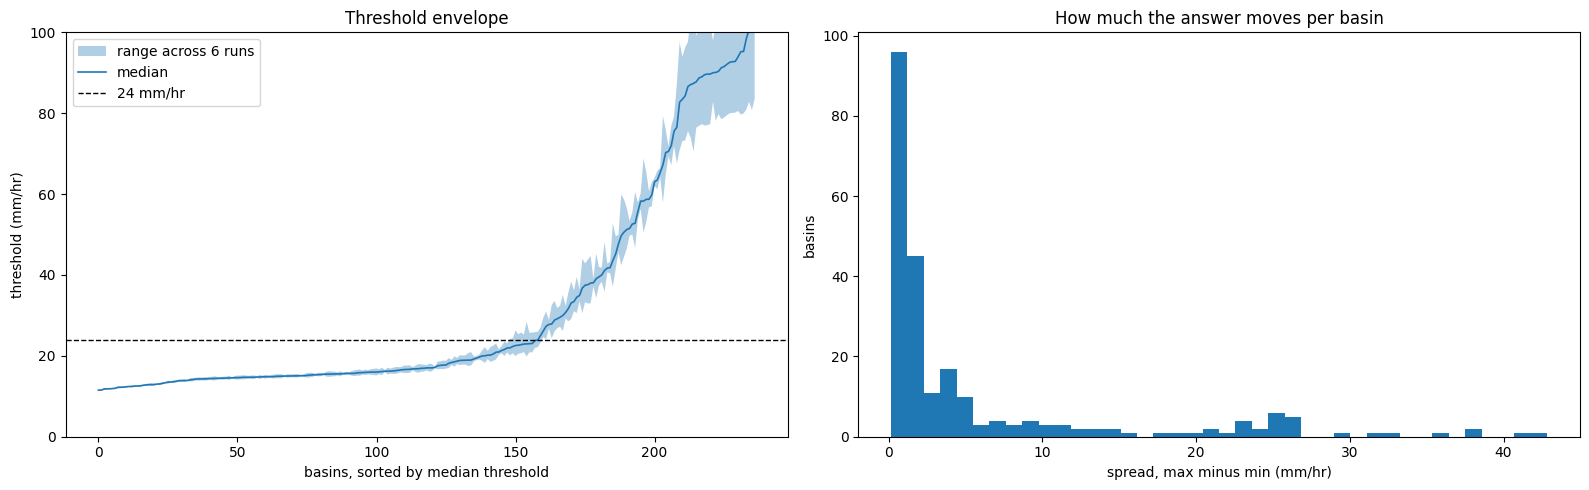

In [11]:
# Cell 10 --- envelope numbers and plot

e = env.copy()
for c in ('threshold_min', 'threshold_median', 'threshold_max', 'threshold_spread'):
    if c in e.columns:
        e[c] = pd.to_numeric(e[c], errors='coerce').replace([np.inf, -np.inf], np.nan)

MIN_C, MED_C, MAX_C = 'threshold_min', 'threshold_median', 'threshold_max'
SPREAD_C = 'threshold_spread'

print('--- Rainfall threshold envelope across the six envelope runs ---')
print(e[[MIN_C, MED_C, MAX_C, SPREAD_C]].describe().round(2).to_string())

finite = e[e[SPREAD_C].notna()]
print(f'\nmedian basin: {finite[MED_C].median():.1f} mm/hr, '
      f'ranging {finite[MIN_C].median():.1f} to {finite[MAX_C].median():.1f}')
print(f'median spread across parameter choices: {finite[SPREAD_C].median():.2f} mm/hr')
print(f'basins whose spread exceeds 5 mm/hr : {(finite[SPREAD_C] > 5).sum()}')

order = finite.sort_values(MED_C)
x = np.arange(len(order))
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].fill_between(x, order[MIN_C], order[MAX_C], alpha=0.35,
                   label='range across 6 runs')
ax[0].plot(x, order[MED_C], lw=1.2, label='median')
ax[0].axhline(REFERENCE_STORM, color='k', ls='--', lw=1,
              label=f'{REFERENCE_STORM} mm/hr')
ax[0].set_xlabel('basins, sorted by median threshold')
ax[0].set_ylabel('threshold (mm/hr)'); ax[0].set_ylim(0, 100); ax[0].legend()
ax[0].set_title('Threshold envelope')

ax[1].hist(finite[SPREAD_C], bins=40)
ax[1].set_xlabel('spread, max minus min (mm/hr)'); ax[1].set_ylabel('basins')
ax[1].set_title('How much the answer moves per basin')
plt.tight_layout(); plt.show()

---
## Cell 11 — Stability at 24 mm/hr

Three classes per basin, on `p_24 >= 0.6`, which is the definition `hazard_class`
uses and the one every other number in this project uses.

- **always** High under all six parameter choices. The defensible result.
- **sometimes** High. This is where the assumptions are doing the work.
- **never** High.

The `frac_high` column shades the "sometimes" basins by how often, so the map
shows degree rather than a single flat colour.

stability column: stability
stability
always       140
never         80
sometimes     17
always      140 basins,   113.3 km2 (37.2% of basin area)
sometimes    17 basins,    17.1 km2 ( 5.6% of basin area)
never        80 basins,   174.5 km2 (57.2% of basin area)


/tmp/ipykernel_3980/4073829570.py:26: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(); ax[0].axis('off')
/tmp/ipykernel_3980/4073829570.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(); ax[0].axis('off')


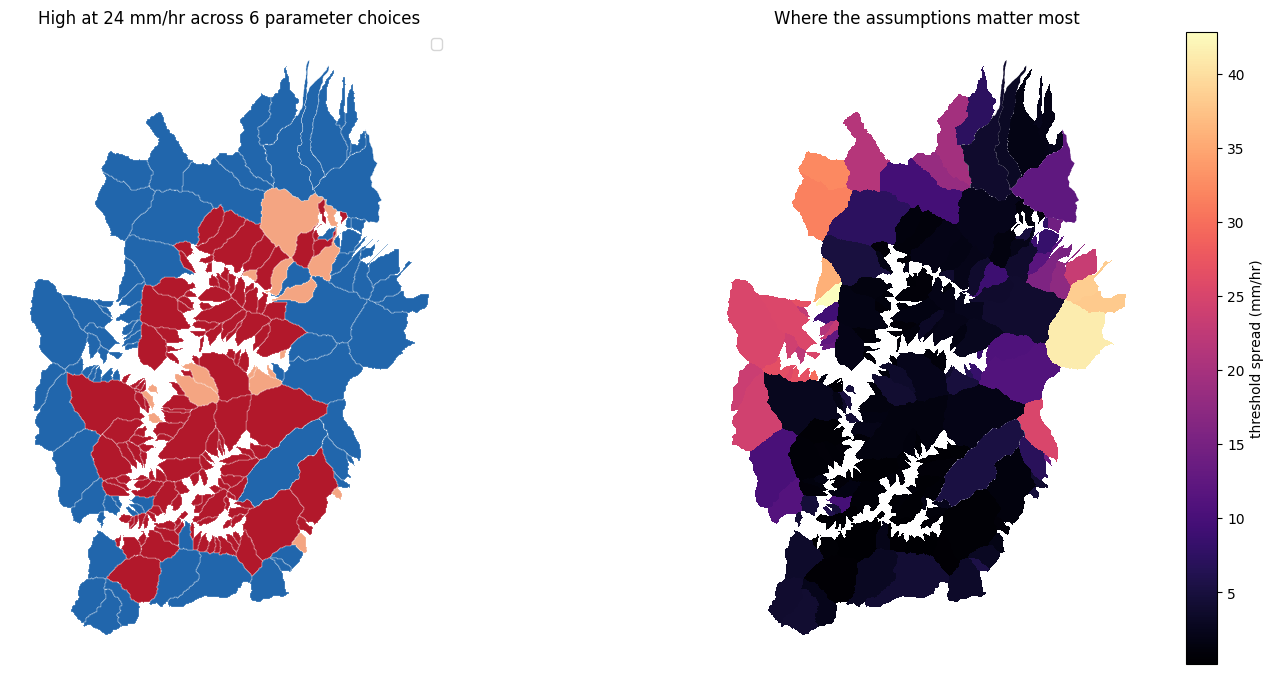

In [12]:
# Cell 11 --- stability classes and map

STAB_COL = [c for c in stab.columns
            if stab[c].dtype == object and c not in ('basin_id',)][0]
print(f'stability column: {STAB_COL}')
print(stab[STAB_COL].value_counts().to_string())

g = basins_gdf.merge(stab, left_on='id', right_on='basin_id', how='left') \
              .merge(e, left_on='id', right_on='basin_id', how='left',
                     suffixes=('', '_env'))

burn_area = g.geometry.area
for cls in ('always', 'sometimes', 'never'):
    sel = g[STAB_COL] == cls
    print(f'{cls:10s} {sel.sum():4d} basins, '
          f'{burn_area[sel].sum()/1e6:7.1f} km2 '
          f'({burn_area[sel].sum()/burn_area.sum():5.1%} of basin area)')

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
colors = {'always': '#b2182b', 'sometimes': '#f4a582', 'never': '#2166ac'}
for cls, col in colors.items():
    sub = g[g[STAB_COL] == cls]
    if len(sub):
        sub.plot(ax=ax[0], color=col, edgecolor='white', linewidth=0.2,
                 label=f'{cls} ({len(sub)})')
ax[0].legend(); ax[0].axis('off')
ax[0].set_title(f'High at {REFERENCE_STORM} mm/hr across 6 parameter choices')

g.plot(column=SPREAD_C, ax=ax[1], cmap='magma', legend=True,
       legend_kwds={'label': 'threshold spread (mm/hr)'})
ax[1].axis('off'); ax[1].set_title('Where the assumptions matter most')
plt.tight_layout(); plt.show()

---
## Cell 12 — The BAER anchors alongside

The anchors are not part of the envelope. They answer a different question: where
does the field-validated severity map fall relative to the range of parameter
choices?

Two cases are worth naming. A basin that is **always** High across every
parameter choice but not High under BAER means the parameter sweep is confidently
wrong about it. A basin that is **never** High but is High under BAER is more
alarming still, since field observation promotes a hazard the sweep never flagged.

If BAER falls outside the envelope for many basins, that is the finding: the
uncertainty from parameter choice is smaller than the uncertainty from which
severity product you use, and an envelope built on parameters alone understates
the real uncertainty.

anchor_agreement columns: ['basin_id', 'run_id', 'stability', 'anchor_p', 'anchor_high', 'agreement']

--- baer_drop ---
  anchor_high               136 basins

--- baer_zero ---
  anchor_high               131 basins

BAER threshold inside the 6-run envelope : 150 of 237 (63.3%)
above the envelope maximum (less hazardous): 87
below the envelope minimum (more hazardous): 0


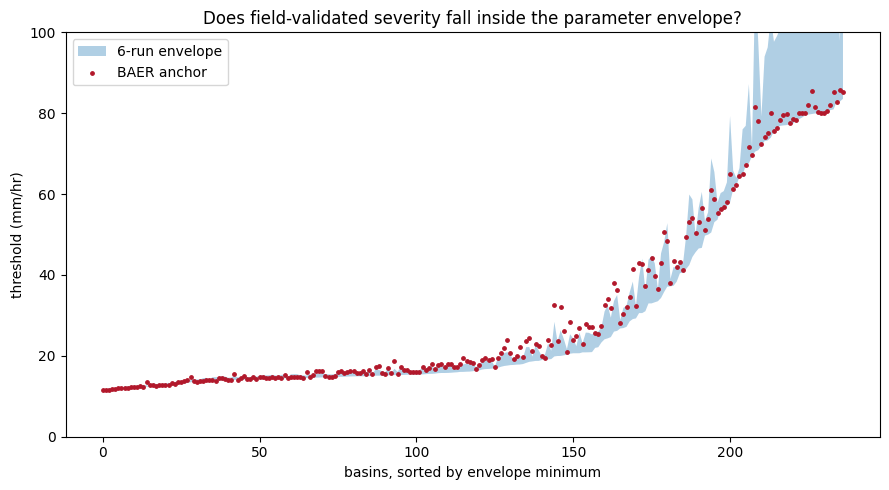

In [13]:
# Cell 12 --- anchors against the envelope

print('anchor_agreement columns:', list(anch.columns))
print()
for run_id in ANCHOR_RUNS:
    sub = anch[anch.run_id == run_id] if 'run_id' in anch.columns else anch
    print(f'--- {run_id} ---')
    for c in sub.columns:
        if sub[c].dtype == bool:
            print(f'  {c:24s} {int(sub[c].sum()):4d} basins')
    print()

# Where does the BAER threshold sit relative to the envelope?
baer_thr = runs_df[runs_df.run_id == 'baer_drop'].set_index('basin_id')['threshold_mm_hr']
cmp_df = e.set_index('basin_id') if 'basin_id' in e.columns else e.copy()
cmp_df = cmp_df.join(baer_thr.rename('baer_threshold'))
ok = cmp_df[[MIN_C, MAX_C, 'baer_threshold']].replace([np.inf, -np.inf], np.nan).dropna()
inside = ((ok.baer_threshold >= ok[MIN_C]) & (ok.baer_threshold <= ok[MAX_C]))
print(f'BAER threshold inside the 6-run envelope : {inside.sum()} of {len(ok)} '
      f'({inside.mean():.1%})')
print(f'above the envelope maximum (less hazardous): '
      f'{(ok.baer_threshold > ok[MAX_C]).sum()}')
print(f'below the envelope minimum (more hazardous): '
      f'{(ok.baer_threshold < ok[MIN_C]).sum()}')

fig, ax = plt.subplots(figsize=(9, 5))
o = ok.sort_values(MIN_C)
xx = np.arange(len(o))
ax.fill_between(xx, o[MIN_C], o[MAX_C], alpha=0.35, label='6-run envelope')
ax.scatter(xx, o.baer_threshold, s=6, color='#b2182b', label='BAER anchor')
ax.set_ylim(0, 100); ax.set_xlabel('basins, sorted by envelope minimum')
ax.set_ylabel('threshold (mm/hr)'); ax.legend()
ax.set_title('Does field-validated severity fall inside the parameter envelope?')
plt.tight_layout(); plt.show()

In [14]:
print(anch.groupby(['run_id', 'stability', 'agreement']).size().to_string())

run_id     stability  agreement               
baer_drop  always     confirms_high               135
                      contradicts_high              5
           never      confirms_not_high            80
           sometimes  unstable_anchor_high          1
                      unstable_anchor_not_high     16
baer_zero  always     confirms_high               131
                      contradicts_high              9
           never      confirms_not_high            80
           sometimes  unstable_anchor_not_high     17


In [15]:
worst = anch[(anch.run_id == 'baer_drop') & (anch.agreement == 'contradicts_high')]
print(basins_gdf.merge(worst, left_on='id', right_on='basin_id')
      [['id', 'area_km2', 'burned_cells']].to_string(index=False))
print(runs_df[(runs_df.run_id.isin(['t270_drop','baer_drop'])) &
              (runs_df.basin_id.isin(worst.basin_id))]
      .pivot(index='basin_id', columns='run_id',
             values=['T','threshold_mm_hr']).round(3).to_string())

 id  area_km2  burned_cells
  9    7.1540         63309
114    0.7637          7637
131    0.5591          4811
208    0.2560          2560
334    0.1147          1147
                 T           threshold_mm_hr          
run_id   baer_drop t270_drop       baer_drop t270_drop
basin_id                                              
9            0.387     0.636          22.360    19.327
114          0.413     0.758          21.848    18.014
131          0.409     0.668          22.627    19.421
208          0.343     0.670          22.069    18.334
334          0.344     0.801          23.932    18.278


---
## Cell 13 — Save everything

The long frame goes out whole, so a different High cutoff or a subset of runs can
be re-aggregated from the CSV without touching a raster again.

The GeoJSON carries the envelope, the stability class and the anchor flags joined
to basin geometry. That is the file the web map wants and it is already in the
shape tippecanoe expects.

In [16]:
# Cell 13 --- write outputs

runs_df.to_csv(OUT_DIR / 'sensitivity_runs_long.csv', index=False)
env.to_csv(OUT_DIR / 'sensitivity_envelope.csv', index=False)
stab.to_csv(OUT_DIR / 'sensitivity_stability.csv', index=False)
anch.to_csv(OUT_DIR / 'sensitivity_anchors.csv', index=False)

anchor_wide = anch.pivot_table(index='basin_id', columns='run_id',
                               values=[c for c in anch.columns
                                       if anch[c].dtype == bool],
                               aggfunc='first') if 'run_id' in anch.columns else None
gout = g.copy()
if anchor_wide is not None:
    anchor_wide.columns = ['_'.join(map(str, c)) for c in anchor_wide.columns]
    gout = gout.merge(anchor_wide.reset_index(), left_on='id',
                      right_on='basin_id', how='left', suffixes=('', '_a'))
gout = gout.loc[:, ~gout.columns.duplicated()]
for c in gout.columns:
    if gout[c].dtype == bool:
        gout[c] = gout[c].astype(int)
gout.to_file(OUT_DIR / 'bridge_2024_sensitivity.geojson', driver='GeoJSON')

findings = {
    'design': {'envelope_runs': ENVELOPE_RUNS, 'anchor_runs': ANCHOR_RUNS,
               'dnbr_levels': DNBR_LEVELS, 'soil_rules': list(SOIL_RULES),
               'basins': len(BASIN_IDS), 'rows': int(len(runs_df)),
               'reference_storm_mm_hr': REFERENCE_STORM,
               'high_cutoff_p': float(sensitivity.HIGH_P)},
    'envelope': {
        'median_of_medians': float(finite[MED_C].median()),
        'median_of_minima': float(finite[MIN_C].median()),
        'median_of_maxima': float(finite[MAX_C].median()),
        'median_spread': float(finite[SPREAD_C].median()),
        'basins_spread_over_5': int((finite[SPREAD_C] > 5).sum()),
    },
    'stability': stab[STAB_COL].value_counts().to_dict(),
    'anchors': {'baer_inside_envelope': int(inside.sum()),
                'baer_above_max': int((ok.baer_threshold > ok[MAX_C]).sum()),
                'baer_below_min': int((ok.baer_threshold < ok[MIN_C]).sum()),
                'n_compared': int(len(ok))},
}
with open(OUT_DIR / 'sensitivity_findings.json', 'w') as f:
    json.dump(findings, f, indent=2, default=str)

for p in sorted(OUT_DIR.glob('sensitivity_*')):
    print(f'saved -> {p.name}')
print(f'saved -> bridge_2024_sensitivity.geojson')
print()
print(json.dumps(findings['envelope'], indent=2))

saved -> sensitivity_anchors.csv
saved -> sensitivity_envelope.csv
saved -> sensitivity_findings.json
saved -> sensitivity_runs_long.csv
saved -> sensitivity_stability.csv
saved -> bridge_2024_sensitivity.geojson

{
  "median_of_medians": 17.01846658197475,
  "median_of_minima": 16.195043712835286,
  "median_of_maxima": 17.889445448759584,
  "median_spread": 1.7017175050922848,
  "basins_spread_over_5": 62
}


---
## Cell 14 — Export for the web map

The map reads two files: a manifest listing the fires available, and one GeoJSON
per fire. Nothing else. That contract is deliberately small so the same map can
later be pointed at a file written on demand by a server rather than precomputed
here, without changing the map at all.

**No geometry simplification.** An earlier version of this cell simplified the
polygons to reduce file size, which was a mistake. `simplify()` operates on each
polygon independently, so two basins sharing an exact boundary have that boundary
simplified twice and separately, producing two slightly different lines. The
result is a sliver or an overlap along every shared edge in the dataset. At 237
basins the unsimplified file is under a megabyte, so there is nothing to gain and
a topology problem to lose.

Coordinate rounding is safe by contrast, because a shared vertex has identical
coordinates in both polygons and therefore rounds to the same place.

**Tiny disconnected parts are dropped, for display only.** D8 flow routing sends
water to one of eight neighbours, so a headwater flow path can be a single cell
wide running diagonally. Polygonisation merges cells that share an edge but not
cells that touch only at a corner, so those diagonal chains come out as strings
of detached one-cell diamonds. They are correct: those cells really do drain to
that basin's outlet. They also look like a broken dataset, and explaining
eight-direction corner connectivity in a map legend is not realistic.

So parts below a size threshold are dropped from the **web copy only**. This is a
display decision, not a data correction. The analysis geometry in
`terrain/bridge_2024_basins.geojson` is untouched, every statistic in this project
was computed on the full raster, and the cell reports how much area is removed so
the cost is visible rather than silent.

Download both output files from Drive afterwards and put them in `web/data/`.

In [17]:
# Cell 14 --- export the web map data

import json
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPolygon

WEB_DIR = FIRE_DIR / 'web_export'
WEB_DIR.mkdir(parents=True, exist_ok=True)

FIRE_ID = 'bridge_2024'
FIRE_NAME = 'Bridge Fire'

# Parts smaller than this are dropped from the web copy. Ten 10 m cells.
MIN_PART_M2 = 1000.0

# --- Assemble the per-basin table ---------------------------------------------
baseline_run = runs_df[runs_df.run_id == 't270_drop'].set_index('basin_id')
baer_run = runs_df[runs_df.run_id == 'baer_drop'].set_index('basin_id')

env_i = env.set_index('basin_id')
stab_i = stab.set_index('basin_id')
anch_i = anch[anch.run_id == 'baer_drop'].set_index('basin_id')

tbl = pd.DataFrame(index=sorted(baseline_run.index))
tbl['T'] = baseline_run['T']
tbl['F'] = baseline_run['F']
tbl['S'] = baseline_run['S']
tbl['p_24'] = baseline_run['p_24']
tbl['threshold_mm_hr'] = baseline_run['threshold_mm_hr']
tbl['thr_min'] = env_i['threshold_min']
tbl['thr_max'] = env_i['threshold_max']
tbl['thr_spread'] = env_i['threshold_spread']
tbl['stability'] = stab_i['stability']
tbl['frac_high'] = stab_i['frac_high']
tbl['baer_threshold'] = baer_run['threshold_mm_hr']
tbl['baer_agreement'] = anch_i['agreement']
tbl = tbl.replace([np.inf, -np.inf], np.nan)

geo = basins_gdf[['id', 'area_km2', 'geometry']].copy()
geo['id'] = geo['id'].astype(int)
web = geo.merge(tbl.reset_index().rename(columns={'index': 'id'}),
                on='id', how='left')

# --- Drop tiny disconnected parts. Display only. ------------------------------
def drop_small_parts(geom, min_area):
    """Keep only polygon parts above min_area. Always keeps the largest one."""
    if geom is None or geom.is_empty:
        return geom
    parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
    if len(parts) == 1:
        return geom
    kept = [p for p in parts if p.area >= min_area]
    if not kept:
        kept = [max(parts, key=lambda p: p.area)]
    return kept[0] if len(kept) == 1 else MultiPolygon(kept)

area_before = web.geometry.area.sum()
parts_before = sum(len(g.geoms) if g.geom_type == 'MultiPolygon' else 1
                   for g in web.geometry)

web['geometry'] = web.geometry.apply(drop_small_parts, min_area=MIN_PART_M2)

area_after = web.geometry.area.sum()
parts_after = sum(len(g.geoms) if g.geom_type == 'MultiPolygon' else 1
                  for g in web.geometry)
lost = area_before - area_after
print(f'polygon parts : {parts_before:,} -> {parts_after:,} '
      f'({parts_before - parts_after:,} dropped)')
print(f'area removed  : {lost:,.0f} m2 ({lost / area_before:.3%} of basin area)')
if lost / area_before > 0.005:
    print('WARNING: more than 0.5% of area removed. Lower MIN_PART_M2.')

# --- Reproject and round. NO simplify: it breaks shared boundaries. ------------
web = web.to_crs('EPSG:4326')

def round_coords(obj, nd=6):
    if isinstance(obj, (list, tuple)):
        return [round_coords(o, nd) for o in obj]
    if isinstance(obj, float):
        return round(obj, nd)
    return obj

gj = json.loads(web.to_json())
NUMERIC = ['area_km2', 'T', 'F', 'S', 'p_24', 'threshold_mm_hr',
           'thr_min', 'thr_max', 'thr_spread', 'frac_high', 'baer_threshold']
for feat in gj['features']:
    feat['geometry']['coordinates'] = round_coords(feat['geometry']['coordinates'])
    p = feat['properties']
    for k in NUMERIC:
        if k in p and p[k] is not None and p[k] == p[k]:
            p[k] = round(float(p[k]), 3)
        elif k in p:
            p[k] = None
    feat.pop('id', None)

geo_path = WEB_DIR / f'{FIRE_ID}.geojson'
with open(geo_path, 'w') as f:
    json.dump(gj, f, separators=(',', ':'))
size_mb = geo_path.stat().st_size / 1e6
print(f'\n{geo_path.name}: {len(gj["features"])} features, {size_mb:.2f} MB')
if size_mb > 5:
    print('WARNING: unexpectedly large for 237 basins.')

# --- Manifest ------------------------------------------------------------------
b = web.total_bounds
med_thr = float(tbl.threshold_mm_hr.median())
manifest = {
    'generated': pd.Timestamp.utcnow().strftime('%Y-%m-%d'),
    'fires': [{
        'id': FIRE_ID,
        'name': FIRE_NAME,
        'year': 2024,
        'state': 'CA',
        'ignition': '2024-09-08',
        'area_km2': 226.6,
        'center': [round(float(web.geometry.union_all().centroid.x), 4),
                   round(float(web.geometry.union_all().centroid.y), 4)],
        'bounds': [round(float(v), 4) for v in b],
        'basins': int(len(web)),
        'data': f'data/{FIRE_ID}.geojson',
        'severity_source': 'Sentinel-2 dNBR, 2024-08-20 to 2024-09-29',
        'has_baer_anchor': True,
        'median_threshold_mm_hr': round(med_thr, 1),
        'envelope_spread_mm_hr': round(float(env_i.threshold_spread.median()), 2),
        'stability': stab['stability'].value_counts().to_dict(),
    }],
}
man_path = WEB_DIR / 'fires.json'
with open(man_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f'{man_path.name} written')
print(f'\nDownload both from {WEB_DIR} and put them in web/data/')

polygon parts : 411 -> 237 (174 dropped)
area removed  : 18,800 m2 (0.006% of basin area)

bridge_2024.geojson: 237 features, 2.00 MB
fires.json written

Download both from /content/drive/MyDrive/postfire-debris-flow/bridge_2024/web_export and put them in web/data/


---
# Findings

## What this study asked

Notebooks `02b` and `03` asked whether this pipeline is anchored in the right
place. This one asks a different question: **how much does the answer move under
defensible alternative choices?** USGS publishes single-scenario assessments with
no uncertainty bounds, so this is the piece that is genuinely additional.

Two axes, chosen because the earlier comparison work showed they are the two that
matter: the dNBR threshold for moderate-or-high severity at 200, 270 and 350, and
soil KF null handling either dropped and renormalised or zeroed. Six runs over
237 fixed basins.

Two further runs use the BAER field-validated soil burn severity map in place of
a dNBR threshold, one per soil rule. These are reported **alongside** the
envelope rather than inside it. The three thresholds are one measurement with a
parameter varied, which is what an uncertainty envelope means; BAER is a different
instrument, hand-corrected from field observation. Folding it in would have made
the envelope width partly a data-source difference wearing a parameter costume,
and would have hidden the result below.

F is the basin-mean dNBR with no threshold in its definition, so it is constant
across all eight runs. Every bit of spread therefore comes from T and S, which
makes the study fully attributable by construction with no variance decomposition
needed.

## Correctness check

The `t270_drop` run is exactly the configuration that produced the published
baseline in notebook 01. It reproduces that file at machine precision: T, F,
threshold and p_24 all at 0.000e+00 maximum absolute difference, S at 8.3e-17,
which is a single float64 rounding step. That confirms grid alignment, the 2x2
block expansion of the 20 m severity raster onto the 10 m grid, the live soil
query, the area weighting and the rainfall convention in one check.

## The envelope: the answer barely moves

| | mm/hr |
|---|---|
| median basin, median across runs | 17.0 |
| median basin, minimum across runs | 16.2 |
| median basin, maximum across runs | 17.9 |
| **median spread, max minus min** | **1.70** |
| basins with spread above 5 mm/hr | 62 of 237 |

Across every combination of severity threshold and soil rule, the median basin's
rainfall threshold sits between 16.2 and 17.9 mm/hr.

**For scale, that 1.70 mm/hr spread sits against a 7.7 mm/hr disagreement with
the USGS operational assessment.** Parameter choice contributes roughly a fifth
of what data-source choice does.

**Where the assumptions matter is spatially structured.** The 62 basins with
spreads above 5 mm/hr are all peripheral: basins that clip the fire edge, where T
is small and the model is extrapolating far from its calibration range. The core
of the burn scar is close to insensitive. That pattern is visible in the spread
map and is what one would want to be true of a hazard product.

## Stability at 24 mm/hr

Classified on `p_24 >= 0.6`, the definition `hazard_class` uses and the one every
other number in this project uses.

| Class | Basins | Area | Share of basin area |
|---|---|---|---|
| always High | 140 | 113.3 km² | 37.2% |
| sometimes High | 17 | 17.1 km² | 5.6% |
| never High | 80 | 174.5 km² | 57.2% |

Only 17 basins, covering 5.6% of the area, change class depending on the
assumptions. The hazard map is robust to how the parameters are set.

## The anchor result

This is the most important finding in the study, and it only exists because the
BAER runs were kept outside the envelope.

**87 of 237 basins have their BAER threshold above the envelope maximum. Zero
fall below it.**

If the field-validated map were simply a noisy alternative, roughly half the
basins would fall on each side. All 87 falling on one side is a directional
result: relative to ground truth, the parameter sweep is systematically biased
toward more hazard. The envelope built from parameter choices alone therefore
**understates** the real uncertainty.

Comparing the anchors against the stability classes:

| Stability class | BAER agrees | BAER disagrees |
|---|---|---|
| never High (80) | **80** | 0 |
| always High (140) | 135 | 5 |
| sometimes High (17) | 16 not High | 1 High |

Under the zeroed soil rule the pattern is the same: 80 of 80, 131 of 140, and all
17 unstable basins resolving to not High.

**Every basin the parameter sweep calls never-High is confirmed not High by field
observation. Both soil rules, no exceptions.** For a hazard product this is the
failure mode that matters: no dangerous canyon has been called safe. It is also
consistent with `02b`, where 99.8% of the ground USGS rates High was also rated
High here.

The disagreements all run one way. BAER never promotes a basin the sweep missed;
it only demotes basins the sweep flagged. **This pipeline over-warns and does not
under-warn**, at least on this fire, which is the right direction for a hazard
product to be wrong in.

### The contradicted basins are marginal, not wrong

The five always-High basins that BAER downgrades under the dropped soil rule:

| Basin | Area km² | T, dNBR 270 | T, BAER | Threshold, dNBR | Threshold, BAER |
|---|---|---|---|---|---|
| 9 | 7.15 | 0.636 | 0.387 | 19.33 | 22.36 |
| 114 | 0.76 | 0.758 | 0.413 | 18.01 | 21.85 |
| 131 | 0.56 | 0.668 | 0.409 | 19.42 | 22.63 |
| 208 | 0.26 | 0.670 | 0.343 | 18.33 | 22.07 |
| 334 | 0.11 | 0.801 | 0.344 | 18.28 | 23.93 |

T roughly halves in each, but every BAER threshold lands between 21.8 and 23.9
mm/hr, just below the 24 mm/hr evaluation storm. These are not basins where the
two severity sources reach opposite conclusions. They are basins sitting on the
class boundary, where p is a little above 0.6 under one input and a little below
under the other. Evaluated at a heavier storm most would agree again.

Basin 9 is the only large one at 7.15 km² and 63,309 burned cells. The other four
are under 0.8 km².

## Limitations

**One fire.** The direction of bias is consistent within the Bridge Fire but
cannot be generalised from a single case. Chaparral is where vegetation dNBR and
soil burn severity diverge most, so the effect is plausibly smaller in forested
fuels.

**Scene pair is not an axis.** Testing it would require two more full Sentinel-2
ingests, and `02b` found F agrees with the USGS assessment at r = 0.965, so it is
likely the most stable input and the most expensive to vary.

**Delineation scale is not an axis.** Notebook `03` tested it across a 25-fold
range of minimum basin area and found it moves the area-weighted threshold by
0.35 mm/hr. Including it would have added runs without adding information.

**Area weighting differs from notebook 03.** Figures here are weighted by total
basin area; notebook 03 weighted by burned cells per basin. Since only 65% of
basin area burned, the area-weighted T here reads lower (0.378 against 0.670 for
the same run). Plain medians match exactly between the two notebooks. The two
weightings answer different questions and neither is wrong.

## What to take from this

1. The hazard map is robust to parameter choice. Median spread 1.70 mm/hr, and
   only 17 of 237 basins change class.
2. The uncertainty that matters is in the input data, not the knobs. Data source
   moves the answer roughly five times as much as parameter choice.
3. The pipeline is conservative. It over-warns relative to field-validated
   severity and, on this fire, never under-warns.